Tesla Gigafactory - Critical Downtime (>60 min):
           Machine  Downtime_Min          Reason  Shift
1   Battery Line 4           135   Cell Overheat  Night
3      Paint Booth           110    HVAC Failure  Night
5  Assembly Line 7            95  Conveyor Stall  Night
0      Gigapress A            75  Hydraulic Leak    Day


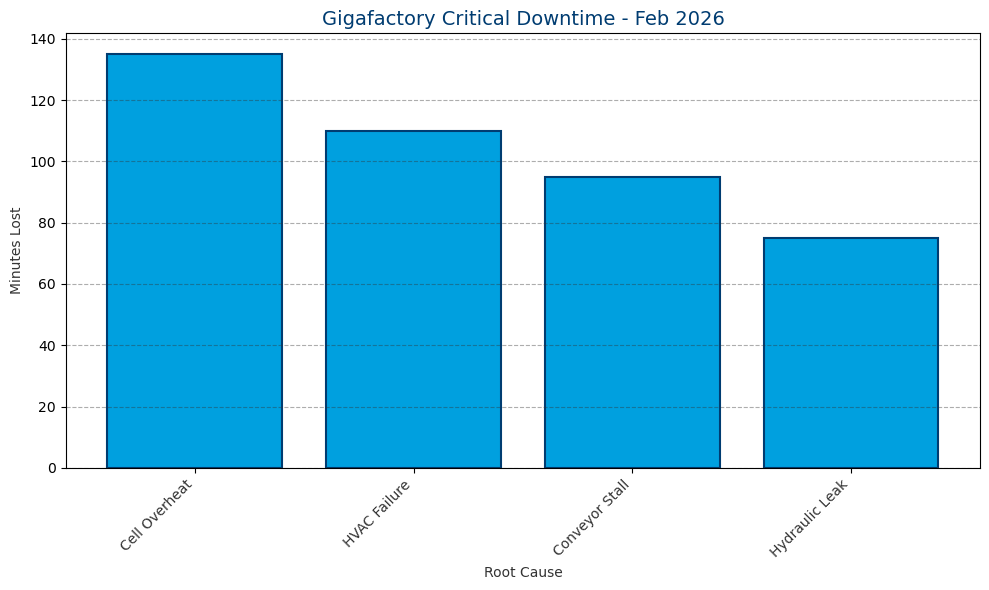

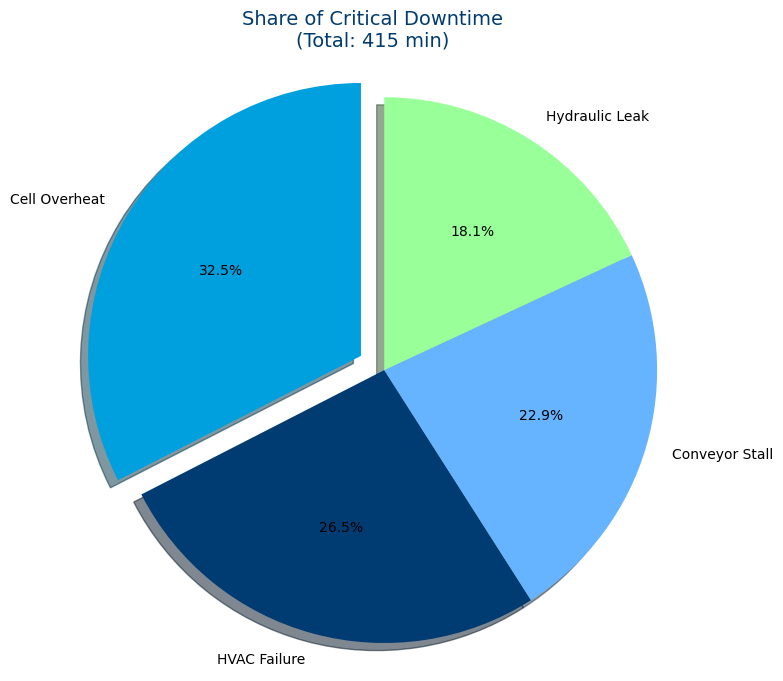

Charts saved:
- tesla_bar_downtime_blue.png
- tesla_pie_downtime_blue.png
Now they look straight out of the Gigafactory—use these in your interview.


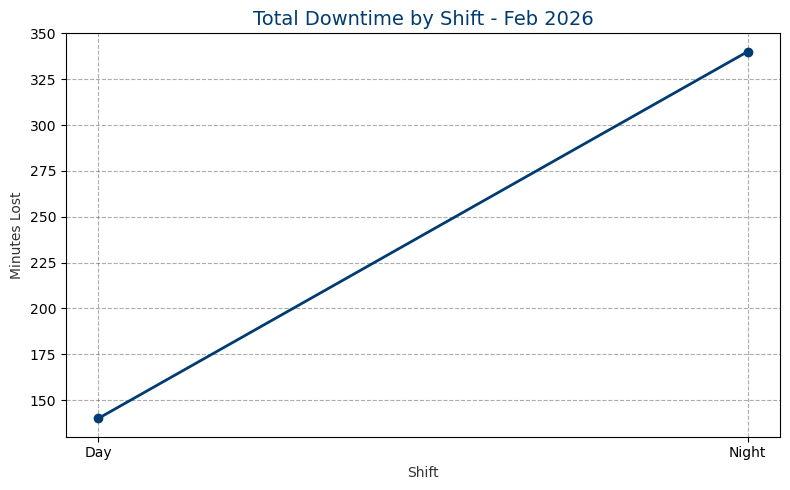

Line chart saved: tesla_line_downtime_blue.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Tesla-style dataset: Gigafactory production log
data = {
'Machine': ['Gigapress A', 'Battery Line 4', 'Gigapress B', 'Paint Booth', 'Battery Line 4', 'Assembly Line 7'],
'Downtime_Min': [75, 135, 40, 110, 25, 95],
'Reason': ['Hydraulic Leak', 'Cell Overheat', 'Tooling Jam', 'HVAC Failure', 'Robot Calibration', 'Conveyor Stall'],
'Shift': ['Day', 'Night', 'Day', 'Night', 'Day', 'Night']
}

df = pd.DataFrame(data)

# Filter for critical stops (>60 min)
df_critical = df[df['Downtime_Min'] > 60].sort_values('Downtime_Min', ascending=False)

print("Tesla Gigafactory - Critical Downtime (>60 min):")
print(df_critical)

# Tesla Blue colors
tesla_blue = '#003C71' # Deep Tesla blue
tesla_light_blue = '#00A0DF' # Accent blue
tesla_gray = '#333333' # For text/grid

# Bar chart - Tesla style
plt.figure(figsize=(10, 6))
plt.bar(df_critical['Reason'], df_critical['Downtime_Min'],
color=tesla_light_blue, edgecolor=tesla_blue, linewidth=1.5)
plt.title('Gigafactory Critical Downtime - Feb 2026', color=tesla_blue, fontsize=14)
plt.xlabel('Root Cause', color=tesla_gray)
plt.ylabel('Minutes Lost', color=tesla_gray)
plt.xticks(rotation=45, ha='right', color=tesla_gray)
plt.grid(axis='y', linestyle='--', alpha=0.4, color=tesla_gray)
plt.tight_layout()
plt.savefig('tesla_bar_downtime_blue.png')
plt.show()

# Pie chart - Tesla blue palette (now with dynamic explode)
num_slices = len(df_critical) # Get actual number of items
explode = [0.1] + [0] * (num_slices - 1) # Pop out only the first (biggest) slice

plt.figure(figsize=(8, 8))
plt.pie(df_critical['Downtime_Min'],
labels=df_critical['Reason'],
autopct='%1.1f%%',
colors=[tesla_light_blue, tesla_blue, '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0'][:num_slices], # Slice colors to match length
startangle=90,
shadow=True,
explode=explode)
plt.title('Share of Critical Downtime\n(Total: ' + str(df_critical['Downtime_Min'].sum()) + ' min)',
color=tesla_blue, fontsize=14)
plt.axis('equal')
plt.savefig('tesla_pie_downtime_blue.png')
plt.show()

print("Charts saved:")
print("- tesla_bar_downtime_blue.png")
print("- tesla_pie_downtime_blue.png")
print("Now they look straight out of the Gigafactory—use these in your interview.")

# Line chart - Downtime by shift
df_shift = df.groupby('Shift')['Downtime_Min'].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(df_shift['Shift'], df_shift['Downtime_Min'], marker='o', color=tesla_blue, linewidth=2)
plt.title('Total Downtime by Shift - Feb 2026', color=tesla_blue, fontsize=14)
plt.xlabel('Shift', color=tesla_gray)
plt.ylabel('Minutes Lost', color=tesla_gray)
plt.grid(True, linestyle='--', alpha=0.4, color=tesla_gray)
plt.tight_layout()
plt.savefig('tesla_line_downtime_blue.png')
plt.show()

print("Line chart saved: tesla_line_downtime_blue.png")
